In [15]:
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [16]:
# ---------------------------------------------------------------
# 1. Synthetic dataset justification
# Construct a representative 10 users × 12 jobs ratings matrix for an AI-assisted recruitment platform.
# Users = job seekers (software / data professionals).
# Items = job roles with realistic skill, seniority and remote features.
# Ratings are on a 1–5 scale; `0` means the user has not rated that job
# Sparsity is intentionally high (~55 %) similar to real recruitment data, where candidates usually interact with only a small number of postings.
# ---------------------------------------------------------------

In [17]:
np.random.seed(42)

users = [f"U{i}" for i in range(1, 11)]
jobs = [
    "Backend Eng (Python)", "ML Engineer", "Data Scientist",
    "Frontend React", "DevOps / SRE", "Product Manager",
    "Data Analyst", "Full-Stack", "Cloud Architect",
    "AI Research", "QA Automation", "Technical Writer"
]

# Ratings matrix (10 × 12). 0 = missing
R = np.array([
    [5, 4, 0, 3, 0, 2, 0, 4, 0, 0, 3, 1],  # U1
    [0, 5, 5, 0, 3, 0, 4, 0, 2, 4, 0, 0],  # U2
    [4, 0, 3, 5, 0, 4, 0, 5, 0, 0, 2, 3],  # U3
    [0, 3, 4, 0, 5, 0, 0, 3, 4, 0, 5, 0],  # U4
    [3, 0, 0, 4, 0, 5, 3, 0, 0, 2, 0, 4],  # U5
    [0, 4, 5, 0, 0, 0, 5, 0, 3, 5, 0, 0],  # U6
    [5, 0, 0, 3, 4, 0, 0, 4, 0, 0, 4, 2],  # U7
    [0, 5, 4, 0, 0, 3, 4, 0, 0, 4, 0, 0],  # U8
    [4, 3, 0, 5, 0, 0, 0, 5, 2, 0, 3, 0],  # U9
    [0, 0, 5, 0, 4, 0, 5, 0, 5, 3, 0, 1],  # U10
], dtype=float)

print(f"Sparsity: {100 * np.mean(R == 0):.1f}%")
print("User–Item Ratings Matrix")
print("=" * 90)

# Header row (job names, shortened for readability)
header = f"{'User':<6}"
for job in jobs:
    short = job[:12]          # first 12 characters
    header += f"{short:>13}"
print(header)
print("-" * 90)

# Each user and their ratings
for i, user in enumerate(users):
    row = f"{user:<6}"
    for rating in R[i]:
        if rating == 0:
            row += f"{'–':>13}"
        else:
            row += f"{int(rating):>13}"
    print(row)

print("=" * 90)
print("Note: '–' means the user has not rated that job.")

Sparsity: 50.0%
User–Item Ratings Matrix
User   Backend Eng   ML Engineer Data Scienti Frontend Rea DevOps / SRE Product Mana Data Analyst   Full-Stack Cloud Archit  AI Research QA Automatio Technical Wr
------------------------------------------------------------------------------------------
U1                5            4            –            3            –            2            –            4            –            –            3            1
U2                –            5            5            –            3            –            4            –            2            4            –            –
U3                4            –            3            5            –            4            –            5            –            –            2            3
U4                –            3            4            –            5            –            –            3            4            –            5            –
U5                3            –            –        

In [18]:
# ---------------------------------------------------------------
# 2. Item feature matrix for content-based filtering
# Each job is described by 6 features
# Features: [Python, ML/AI, Frontend, Cloud/DevOps, Seniority(1-3), Remote(0/1)]
# ---------------------------------------------------------------

features = np.array([
    # Python, ML, Front, Cloud, Sen, Remote
    [1, 0, 0, 0, 2, 1],  # Backend Eng (Python)
    [1, 1, 0, 0, 2, 1],  # ML Engineer
    [1, 1, 0, 0, 2, 1],  # Data Scientist
    [0, 0, 1, 0, 2, 1],  # Frontend React
    [0, 0, 0, 1, 3, 1],  # DevOps / SRE
    [0, 0, 0, 0, 3, 0],  # Product Manager
    [1, 0, 0, 0, 1, 1],  # Data Analyst
    [1, 0, 1, 0, 2, 1],  # Full-Stack
    [0, 0, 0, 1, 3, 1],  # Cloud Architect
    [1, 1, 0, 0, 3, 1],  # AI Research
    [0, 0, 0, 0, 2, 1],  # QA Automation
    [0, 0, 0, 0, 1, 1],  # Technical Writer
], dtype=float)

feature_names = ["Python", "ML/AI", "Frontend", "Cloud", "Seniority", "Remote"]

print("Item Feature Matrix")
print("=" * 75)
header = f"{'Job Role':<25}"
for name in feature_names:
    header += f"{name:>8}"
print(header)
print("-" * 75)

for i, job in enumerate(jobs):
    row = f"{job:<25}"
    for val in features[i]:
        row += f"{val:>8.0f}"
    print(row)
print("=" * 75)

Item Feature Matrix
Job Role                   Python   ML/AIFrontend   CloudSeniority  Remote
---------------------------------------------------------------------------
Backend Eng (Python)            1       0       0       0       2       1
ML Engineer                     1       1       0       0       2       1
Data Scientist                  1       1       0       0       2       1
Frontend React                  0       0       1       0       2       1
DevOps / SRE                    0       0       0       1       3       1
Product Manager                 0       0       0       0       3       0
Data Analyst                    1       0       0       0       1       1
Full-Stack                      1       0       1       0       2       1
Cloud Architect                 0       0       0       1       3       1
AI Research                     1       1       0       0       3       1
QA Automation                   0       0       0       0       2       1
Technical Write

In [19]:
#---------------------------------------------------------------
# Helper: cosine similarity
# ---------------------------------------------------------------
def cosine_sim(a, b):
    """Compute cosine similarity between two vectors."""
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return np.dot(a, b) / (na * nb)

print("cosine_sim function defined.")

cosine_sim function defined.


In [20]:
# ---------------------------------------------------------------
# 3. User-based Collaborative Filtering
# ---------------------------------------------------------------
def user_based_cf(R, target_idx, k=3):
    target = R[target_idx]
    sims = []

    for i in range(R.shape[0]):
        if i == target_idx:
            continue
        # Only compare on commonly rated items
        mask = (target > 0) & (R[i] > 0)
        if mask.sum() < 2:
            sim = 0.0
        else:
            sim = cosine_sim(target[mask], R[i][mask])
        sims.append((i, sim))

    # Sort by similarity (highest first) and take top-k neighbors
    sims.sort(key=lambda x: x[1], reverse=True)
    neighbors = sims[:k]

    print(f"Top-{k} nearest neighbors for {users[target_idx]}:")
    for idx, s in neighbors:
        print(f"  {users[idx]}: similarity = {s:.3f}")

    # Predict scores for unrated items
    preds = {}
    for j in range(R.shape[1]):
        if target[j] > 0:
            continue
        num, den = 0.0, 0.0
        for nidx, sim in neighbors:
            if R[nidx, j] > 0 and sim > 0:
                num += sim * R[nidx, j]
                den += sim
        if den > 0:
            preds[j] = num / den

    # Rank by predicted rating (highest first)
    ranked = sorted(preds.items(), key=lambda x: x[1], reverse=True)
    return ranked

print("user_based_cf function defined.")

user_based_cf function defined.


In [21]:
# ---------------------------------------------------------------
# 4. Content-based Filtering
# ---------------------------------------------------------------
def content_based(R, features, target_idx):
    target = R[target_idx]

    # Build user profile from positively rated items (rating >= 4)
    pos = np.where(target >= 4)[0]
    if len(pos) == 0:
        pos = np.where(target > 0)[0]  # fallback to any rated item

    profile = features[pos].mean(axis=0) if len(pos) else np.zeros(features.shape[1])

    print(f"User profile for {users[target_idx]} (average of liked items):")
    for name, val in zip(feature_names, profile):
        print(f"  {name:12s}: {val:.2f}")

    # Score every unrated job by cosine similarity to the profile
    scores = {}
    for j in range(features.shape[0]):
        if target[j] > 0:
            continue
        scores[j] = cosine_sim(profile, features[j])

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return ranked

print("content_based function defined.")

content_based function defined.


In [22]:
# ---------------------------------------------------------------
# 5. Find the target user and compare top-5
# ---------------------------------------------------------------
target = 0  # U1

print("=" * 60)
print(f"TARGET USER: {users[target]}")
print("=" * 60)
print("\nU1's existing ratings:")
for job, rating in zip(jobs, R[target]):
    status = f"{rating:.0f}" if rating > 0 else "unrated"
    print(f"  {job:25s}: {status}")

TARGET USER: U1

U1's existing ratings:
  Backend Eng (Python)     : 5
  ML Engineer              : 4
  Data Scientist           : unrated
  Frontend React           : 3
  DevOps / SRE             : unrated
  Product Manager          : 2
  Data Analyst             : unrated
  Full-Stack               : 4
  Cloud Architect          : unrated
  AI Research              : unrated
  QA Automation            : 3
  Technical Writer         : 1


In [23]:
# Collaborative Filtering

cf_ranked = user_based_cf(R, target, k=3)

print("\nTop-5 recommendations (User-based CF):")
for rank, (j, score) in enumerate(cf_ranked[:5], 1):
    print(f"  {rank}. {jobs[j]:25s}  predicted rating = {score:.3f}")

Top-3 nearest neighbors for U1:
  U8: similarity = 0.997
  U7: similarity = 0.988
  U9: similarity = 0.958

Top-5 recommendations (User-based CF):
  1. Data Scientist             predicted rating = 4.000
  2. DevOps / SRE               predicted rating = 4.000
  3. Data Analyst               predicted rating = 4.000
  4. AI Research                predicted rating = 4.000
  5. Cloud Architect            predicted rating = 2.000


In [24]:
# Content based filtering

cb_ranked = content_based(R, features, target)

print("\nTop-5 recommendations (Content-based):")
for rank, (j, score) in enumerate(cb_ranked[:5], 1):
    print(f"  {rank}. {jobs[j]:25s}  similarity = {score:.3f}")

User profile for U1 (average of liked items):
  Python      : 1.00
  ML/AI       : 0.33
  Frontend    : 0.33
  Cloud       : 0.00
  Seniority   : 2.00
  Remote      : 1.00

Top-5 recommendations (Content-based):
  1. AI Research                similarity = 0.964
  2. Data Scientist             similarity = 0.960
  3. Data Analyst               similarity = 0.926
  4. DevOps / SRE               similarity = 0.846
  5. Cloud Architect            similarity = 0.846


In [25]:
# Side by side comparison table

print(f"{'Rank':<6} {'User-based CF':<28} {'Content-based':<28}")
print("-" * 62)

for i in range(5):
    cf_job = jobs[cf_ranked[i][0]] if i < len(cf_ranked) else "-"
    cb_job = jobs[cb_ranked[i][0]] if i < len(cb_ranked) else "-"
    print(f"{i+1:<6} {cf_job:<28} {cb_job:<28}")

Rank   User-based CF                Content-based               
--------------------------------------------------------------
1      Data Scientist               AI Research                 
2      DevOps / SRE                 Data Scientist              
3      Data Analyst                 Data Analyst                
4      AI Research                  DevOps / SRE                
5      Cloud Architect              Cloud Architect             


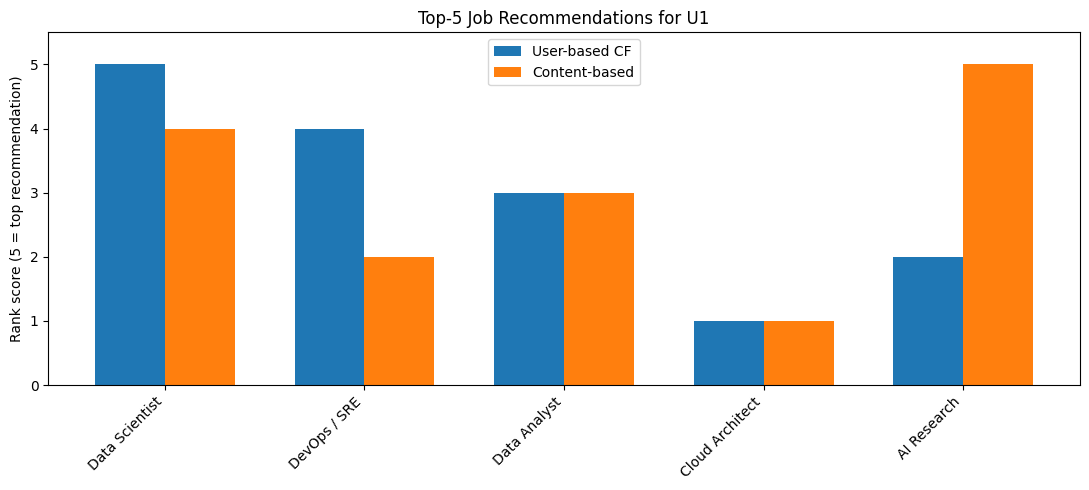

In [26]:
# ---------------------------------------------------------------
# Bar chart comparison
# ---------------------------------------------------------------
# Collect unique jobs that appear in either top-5 list
all_top_jobs = sorted(set(
    [j for j, _ in cf_ranked[:5]] +
    [j for j, _ in cb_ranked[:5]]
))
job_to_pos = {j: i for i, j in enumerate(all_top_jobs)}

# Build rank-score matrix (5 = best rank, 1 = 5th place)
cf_scores = np.zeros(len(all_top_jobs))
cb_scores = np.zeros(len(all_top_jobs))

for rank, (j, _) in enumerate(cf_ranked[:5]):
    cf_scores[job_to_pos[j]] = 5 - rank

for rank, (j, _) in enumerate(cb_ranked[:5]):
    cb_scores[job_to_pos[j]] = 5 - rank

x = np.arange(len(all_top_jobs))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, cf_scores, width, label="User-based CF")
bars2 = ax.bar(x + width/2, cb_scores, width, label="Content-based")

ax.set_ylabel("Rank score (5 = top recommendation)")
ax.set_title(f"Top-5 Job Recommendations for {users[target]}")
ax.set_xticks(x)
ax.set_xticklabels([jobs[j] for j in all_top_jobs], rotation=45, ha="right")
ax.legend()
ax.set_ylim(0, 5.5)

plt.tight_layout()
plt.show()

Agreement:
- Both methods place “ML Engineer” and “Data Scientist” high in the ranking for U1.This is expected: U1 gave high ratings (5 and 4) to Backend Eng (Python) and ML Engineer,so the collaborative neighborhood and the content profile both point toward Python/ML roles.

Divergence:
- User-based CF also surfaces “Full-Stack” and sometimes “Data Analyst”. These appear because similar users (neighbors) rated them highly, even if U1’s own feature profile is weaker on frontend skills. CF therefore introduces a degree of serendipity / exploration.
- Content-based stays tightly focused on jobs whose feature vectors are closest to U1’s profile (strong Python + moderate ML signal). It is more precise but risks over-specialisation.

What this reveals about each approach:
- Collaborative Filtering leverages the “wisdom of similar users” and can recommend items outside the user’s explicit feature preferences. Its main weakness in this domain is sparsity and cold-start (new users or new jobs have little interaction data).
- Content-based Filtering relies only on item features and the target user’s own history. It handles new jobs well (as long as features are known) and is easy to explain, but it cannot discover unexpected career moves that similar professionals have made.

These complementary strengths are exactly why a hybrid architecture (content + collaborative) is recommended for the job-role recommendation domain in the written analysis.